<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
《<a href="http://mng.bz/orYv">从零构建大语言模型</a>》(Build a Large Language Model From Scratch) 一书的配套代码，作者 <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>代码仓库: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# 第 4 章：从零实现 GPT 模型以生成文本

In [1]:
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.10.8
torch version: 2.10.0
tiktoken version: 0.12.0


- 本章我们将实现一个类似 GPT 的 LLM 架构；下一章将专注于训练这个 LLM

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/01.webp" width="500px">

**图 4.1 — 本章心智模型：从数据预处理到完整 GPT 模型**

```
┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌──────────────┐
│  分词 &      │ -> │  Embedding   │ -> │ Transformer │ -> │  输出 logits │
│  Tokenizer  │    │  + 位置编码   │    │  Blocks x12 │    │  -> 生成文本  │
└─────────────┘    └──────────────┘    └─────────────┘    └──────────────┘
     Ch.2               Ch.2               Ch.4                Ch.4
```

> 本章将前面章节实现的 attention、LayerNorm、FeedForward 等模块组合成一个完整的 GPT 模型，最终实现文本生成。

&nbsp;
## 4.1 编写 LLM 架构

- 第 1 章讨论了 GPT 和 Llama 等模型，它们逐词生成文本，基于原始 Transformer 架构的 decoder 部分
- 因此，这些 LLM 通常被称为 "decoder-like"（类 decoder）LLM
- 与传统的深度学习模型相比，LLM 规模更大，主要原因在于其庞大的参数数量，而非代码量
- 我们将看到，LLM 架构中许多元素是重复的

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/02.webp" width="400px">

**图 4.2 — Transformer 架构中的 decoder 部分（LLM 的基础）**

```
┌──────────────────────────────┐
│       原始 Transformer        │
│  ┌────────┐    ┌──────────┐  │
│  │ Encoder │    │  Decoder │  │
│  └────────┘    └──────────┘  │
│                    ↑          │
│              LLM 基于此部分    │
└──────────────────────────────┘
```

> GPT 等现代 LLM 仅使用 Transformer 的 decoder 部分，通过自回归方式逐个生成 token。

- 在前几章中，我们使用了较小的 embedding 维度来表示 token 的输入和输出，以便于说明，确保它们能放在一页内展示
- 本章中，我们考虑使用类似于小型 GPT-2 模型的 embedding 和模型尺寸
- 我们将专门编写最小 GPT-2 模型（1.24 亿参数）的架构，如 Radford 等人的论文 [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) 所述（注意：最初报告将其列为 1.17 亿参数，但后来在模型权重仓库中做了更正）
- 第 6 章将展示如何将预训练权重加载到我们的实现中，届时将兼容 3.45 亿、7.62 亿和 15.42 亿参数的模型尺寸

- 1.24 亿参数 GPT-2 模型的配置详情包括：

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

- 我们使用简短的变量名，以避免后续代码行过长
- `"vocab_size"` 表示词汇表大小为 50,257 个词，由第 2 章讨论的 BPE tokenizer 支持
- `"context_length"` 表示模型的最大输入 token 数量，由第 2 章介绍的位置嵌入（positional embedding）实现
- `"emb_dim"` 是 token 输入的 embedding 维度，将每个输入 token 转换为一个 768 维向量
- `"n_heads"` 是第 3 章实现的多头注意力机制中的注意力头数
- `"n_layers"` 是模型中 transformer block 的数量，我们将在后续章节中实现
- `"drop_rate"` 是 dropout 机制的强度，在第 3 章中讨论过；0.1 表示在训练期间丢弃 10% 的隐藏单元以缓解过拟合
- `"qkv_bias"` 决定第 3 章多头注意力机制中的 `Linear` 层在计算 query (Q)、key (K) 和 value (V) 张量时是否包含偏置向量；我们将禁用此选项，这是现代 LLM 的标准做法；但在第 6 章加载 OpenAI 的预训练 GPT-2 权重到我们的实现时，我们会重新考虑这个设置

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/03.webp" width="500px">

**图 4.3 — GPT 模型的整体架构概览**

```
 输入 token IDs
       │
       ▼
┌──────────────┐
│ Token Embed  │
│ + Pos Embed  │
└──────┬───────┘
       │
       ▼
┌──────────────────┐
│ Transformer Block│ x n_layers
│  ├ Dropout       │
│  ├ LayerNorm     │
│  ├ MultiHeadAtt │
│  ├ FeedForward   │
│  └ ...           │
└──────┬───────────┘
       │
       ▼
┌──────────────┐
│  LayerNorm   │
│  + Linear    │
└──────┬───────┘
       │
       ▼
   输出 logits
```

> 模型的核心是多个堆叠的 transformer block，每个 block 包含 attention 和 FeedForward 子模块。

In [3]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/04.webp?123" width="500px">

**图 4.4 — DummyGPTModel 的数据流：从文本到 logits**

```
"Hello, I am"            ┌───────────┐
         │               │ Tokenizer │
         ▼               └─────┬─────┘
   ┌───────────┐               │
   │ token IDs │<──────────────┘
   └─────┬─────┘
         │
         ▼
   ┌────────────┐    ┌──────────────┐
   │ Token Embed│ +  │ Position Embed│
   └─────┬──────┘    └──────┬───────┘
         └────────┬─────────┘
                  ▼
         ┌──────────────┐
         │    Dropout    │
         └──────┬───────┘
                ▼
         ┌──────────────┐
         │ Output Linear│ -> logits [batch, n_tokens, vocab_size]
         └──────────────┘
```

> DummyGPTModel 让我们验证数据流向：文本 → token → embedding → dropout → logits 输出。

In [4]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [5]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


---

**注意**

- 如果你在 Windows 或 Linux 上运行此代码，上面的输出值可能如下所示：

```
Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)
```

- 由于这些只是随机数，无需担心，你可以继续学习本章的后续内容
- 产生这种差异的一个可能原因是 `nn.Dropout` 在不同操作系统上的行为不同，取决于 PyTorch 的编译方式，详见 [PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

---

&nbsp;
## 4.2 使用 layer normalization 归一化激活值

- Layer normalization（又称 LayerNorm）（[Ba et al. 2016](https://arxiv.org/abs/1607.06450)）将神经网络层的激活值中心化到均值为 0，并将其方差归一化为 1
- 这能稳定训练过程，使模型更快收敛到有效的权重
- Layer normalization 在 transformer block 中的多头注意力模块前后都有应用（我们将在后面实现）；它还在最终输出层之前使用

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/05.webp" width="400px">

**图 4.5 — Layer Normalization 的核心思想**

```
   输入矩阵 (2 个样本, 5 个特征)
   ┌──────────────────────────┐
   │  0.2   0.1  -0.1   0.4   0.5  │ <- 对每一行独立归一化
   │ -0.3   0.2   0.5  -0.6   0.1  │ <- 均值→0, 方差→1
   └──────────────────────────┘
            │
            ▼
   归一化后 (mean=0, var=1)
```

> LayerNorm 对每个样本（行）独立操作，沿特征维度归一化，确保训练稳定性。

- 让我们通过将一个小输入样本传递过一个简单的神经网络层，来看看 layer normalization 是如何工作的：

In [6]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5) 

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


- 让我们计算上面 2 个输入各自的均值和方差：

In [7]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


- 归一化独立地应用于两个输入（行）中的每一行；使用 dim=-1 表示沿最后一个维度（本例中是特征维度）进行计算，而不是行维度

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/06.webp" width="400px">

**图 4.6 — Layer Normalization 沿特征维度操作**

```
  ┌─────────────────────────────────┐
  │  Sample 1: [v1, v2, v3, v4, v5] │ ← mean=0, var=1
  ├─────────────────────────────────┤
  │  Sample 2: [v1, v2, v3, v4, v5] │ ← mean=0, var=1
  └─────────────────────────────────┘
           dim=-1 (沿此方向)
```

> 关键点：LayerNorm 在特征维度（列方向）上归一化，而非在 batch 维度（行方向）上操作。

- 减去均值并除以方差的平方根（标准差），将输入的中心调整为均值 0、方差 1（沿列/特征维度）：

In [8]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- 每个输入的中心为 0，方差为 1；为了提高可读性，我们可以禁用 PyTorch 的科学计数法：

In [9]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- 上面我们对每个输入的特征进行了归一化
- 现在，利用相同的思想，我们可以实现一个 `LayerNorm` 类：

In [10]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

**缩放与偏移（Scale and shift）**

- 注意，除了通过减去均值和除以方差进行归一化外，我们还添加了两个可训练参数：`scale`（缩放）和 `shift`（偏移）参数
- 初始的 `scale`（乘以 1）和 `shift`（加 0）值不会产生任何效果；但是，`scale` 和 `shift` 是可训练参数，如果在训练过程中模型发现这样做有助于提升训练任务的表现，LLM 会自动调整它们
- 这使得模型能够学习最适合其所处理数据的缩放和偏移
- 注意，在计算方差的平方根之前，我们还添加了一个较小的值（`eps`）；这是为了避免在方差为 0 时出现除以零的错误

**有偏方差（Biased variance）**
- 上面的方差计算中，设置 `unbiased=False` 意味着使用公式 $\frac{\sum_i (x_i - \bar{x})^2}{n}$ 来计算方差，其中 n 是样本大小（这里是特征或列的数量）；该公式不包含 Bessel 校正（即在分母中使用 `n-1`），因此提供的是有偏方差估计
- 对于 LLM 来说，由于 embedding 维度 `n` 非常大，使用 n 和 `n-1` 的差异可以忽略不计
- 然而，GPT-2 在归一化层中使用的是有偏方差进行训练，因此为了与后续章节中加载的预训练权重兼容，我们也采用了这一设置

- 现在让我们在实践中试用 `LayerNorm`：

In [11]:
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

In [12]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


- 方差不完全是 1，因为我们使用了 `eps`

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/07.webp" width="400px">

**图 4.7 — 完整的 LayerNorm：归一化 + 可学习的缩放与偏移**

```
   输入 x
     │
     ▼
 ┌────────────────┐
 │ 减去均值 μ      │
 │ 除以标准差 σ+ε  │
 └───────┬────────┘
         │
         ▼
 ┌───────────────┐
 │  × scale (γ)  │  ← 可训练参数
 │  + shift (β)  │  ← 可训练参数
 └───────┬───────┘
         │
         ▼
      输出 y
```

> LayerNorm 不只是做标准化，还通过 scale/shift 让模型自己决定最优的激活值分布。

&nbsp;
## 4.3 实现带有 GELU 激活函数的前馈神经网络

- 本节中，我们实现一个小的神经网络子模块，它被用作 LLM 中 transformer block 的一部分
- 我们从激活函数开始
- 在深度学习中，ReLU（Rectified Linear Unit）激活函数因其简单性和在多种神经网络架构中的有效性而被广泛使用
- 在 LLM 中，除了传统的 ReLU 之外，还使用了其他类型的激活函数；两个典型的例子是 GELU（Gaussian Error Linear Unit）和 SwiGLU（Swish-Gated Linear Unit）
- GELU 和 SwiGLU 是更复杂、更平滑的激活函数，分别结合了高斯分布和 sigmoid 门控线性单元，与 ReLU 简单的分段线性函数相比，为深度学习模型提供了更好的性能

- GELU（[Hendrycks and Gimpel 2016](https://arxiv.org/abs/1606.08415)）可以通过多种方式实现；其精确版本定义为 GELU(x)=x⋅Φ(x)，其中 Φ(x) 是标准高斯分布的累积分布函数
- 在实践中，通常采用计算成本更低的近似实现：$\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)
$（原始的 GPT-2 模型也是使用此近似训练的）

In [13]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

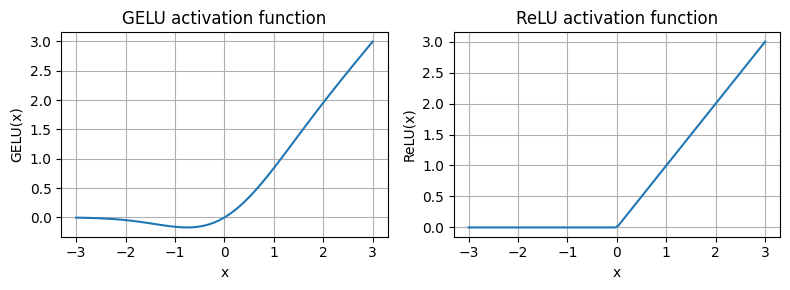

In [14]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

- 如我们所见，ReLU 是一个分段线性函数，当输入为正时直接输出输入值，否则输出零
- GELU 是一个平滑的非线性函数，近似于 ReLU，但对于负值有非零梯度（大约在 -0.75 处除外）

- 接下来，让我们实现将在 LLM 的 transformer block 中使用的小型神经网络模块 `FeedForward`：

In [15]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [16]:
print(GPT_CONFIG_124M["emb_dim"])

768


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/09.webp?12" width="400px">

**图 4.8 — FeedForward 网络的结构**

```
    输入 [batch, n_tokens, 768]
              │
              ▼
    ┌──────────────────┐
    │ Linear(768 → 3072)│  ← 扩展 4 倍
    └────────┬─────────┘
             │
             ▼
    ┌──────────────────┐
    │      GELU        │  ← 激活函数
    └────────┬─────────┘
             │
             ▼
    ┌──────────────────┐
    │ Linear(3072 → 768)│  ← 投影回原维度
    └────────┬─────────┘
             │
             ▼
    输出 [batch, n_tokens, 768]
```

> FeedForward 先将维度扩展 4 倍，经 GELU 激活后再投影回原始维度，增强模型的表达能力。

In [17]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768) 
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/10.webp" width="400px">

**图 4.9 — FeedForward 中各 token 独立处理**

```
   token 1 ──┐
   token 2 ──┤── 每个 token 独立通过
   token 3 ──┤   同一个 FeedForward 网络
              │
              ▼
   ┌─────────────────┐
   │ Linear → GELU   │
   │ → Linear → Drop │
   └────────┬────────┘
            │
   各 token 输出保持
   位置信息不变
```

> 关键特征：FeedForward 对每个 token 位置独立、相同地处理，不混合不同 token 的信息。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/11.webp" width="400px">

**图 4.10 — GELU 与 ReLU 激活函数对比**

```
  输出
   │         ╱ GELU（平滑曲线）
   │        ╱
   │       ╱     ╱ ReLU（折线）
   │      ╱     ╱
   │     ╱     ╱
   │    ╱     ╱
   │   ╱     ╱
   │  ╱     ╱
   │ ╱     ╱
   │╱     ╱
───┼───────────────── 输入
   │╱
   │  GELU 对负值不为零
   │  ReLU 对负值严格为零
```

> GELU 处处可导且对负值不完全截断，这使得梯度流更顺畅，有利于深层网络训练。

&nbsp;
## 4.4 添加快捷连接（shortcut connections）

- 接下来，让我们谈谈 shortcut connections（快捷连接）背后的概念，它也被称为 skip connection（跳跃连接）或 residual connection（残差连接）
- 快捷连接最初是在计算机视觉的深度网络（残差网络）中提出的，用于缓解梯度消失问题
- 快捷连接为梯度在网络中流动创建了一条较短的替代路径
- 这是通过将某一层的输出与更后面一层的输出相加来实现的，通常会跳过中间的一层或多层
- 让我们用一个小型示例网络来说明这个想法：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/12.webp?123" width="400px">

**图 4.11 — Shortcut connection（残差连接）示意图**

```
  输入
   │
   ├──→ Layer 1 ──→ Layer 2 ──→ Layer 3 ──→ ┐
   │                                         │
   └─────────────── + （相加）───────────────┤
                                             │
                                             ▼
                                           输出
   ←── 梯度可通过 shortcut 直接回传 ──→
```

> Shortcut connection 让梯度可以"抄近路"直接回传到浅层，有效防止深层网络的梯度消失。

- 在代码中，它看起来像这样：

In [18]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

- 让我们先打印**没有** shortcut connection 时的梯度值：

In [19]:
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152039906941354
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


- 接下来，让我们打印**有** shortcut connection 时的梯度值：

In [20]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


- 根据上面的输出，我们可以看到 shortcut connections 防止了早期层（靠近 `layer.0` 的层）的梯度消失
- 接下来实现 transformer block 时，我们将使用 shortcut connection 这一概念

&nbsp;
## 4.5 在 transformer block 中连接 attention 和线性层

- 本节中，我们将之前的概念组合成所谓的 transformer block
- transformer block 将上一章的因果多头注意力模块与线性层、以及前几节实现的前馈神经网络结合在一起
- 此外，transformer block 还使用了 dropout 和 shortcut connections

In [21]:
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch03 import MultiHeadAttention

from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/13.webp?1" width="400px">

**图 4.12 — Transformer block 的内部结构**

```
       输入
        │
   ┌────┴────┐
   │ LayerNorm│
   └────┬────┘
        │
   ┌────┴──────────┐         ┌──────────┐
   │ Multi-Head     │         │          │
   │ Attention      │◄───────┤ Shortcut │
   │ (+ Dropout)    │         │  (Add)   │
   └────┬──────────┘         └────┬─────┘
        │                         │
   ┌────┴────┐                    │
   │ LayerNorm│                   │
   └────┬────┘                    │
   ┌────┴──────────┐         ┌────┴─────┐
   │  FeedForward   │         │          │
   │  (+ Dropout)   │◄───────┤ Shortcut │
   └────┬──────────┘         └────┬─────┘
        │                         │
        ▼                         │
       输出 ◄─────────────────────┘
```

> 每个 transformer block 包含两个子模块（attention + FeedForward），各自带有 LayerNorm、dropout 和残差连接。

- 假设我们有 2 个输入样本，每个样本包含 4 个 token，每个 token 是一个 768 维的 embedding 向量；那么这个 transformer block 会依次应用自注意力机制和线性层，产生一个类似大小的输出
- 你可以将输出看作是我们在前一章讨论的上下文向量（context vectors）的增强版本

In [22]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/14.webp?1" width="400px">

**图 4.13 — Transformer block 中数据的维度变化**

```
  [batch=2, tokens=4, emb=768]
        │
        ▼
  ┌──────────────────────────────┐
  │     Transformer Block        │
  │  ┌────────────────────────┐  │
  │  │ 输入维度保持不变         │  │
  │  │ [2, 4, 768] → [2, 4, 768]│  │
  │  └────────────────────────┘  │
  └──────────────┬───────────────┘
        │
        ▼
  [batch=2, tokens=4, emb=768]  ← 维度不变！
```

> transformer block 的输入输出维度完全相同，这使得可以将多个 block 串联堆叠。

&nbsp;
## 4.6 编写 GPT 模型

- 我们即将完成了：现在让我们将 transformer block 插入本章最开始编写的架构中，以获得一个可用的 GPT 架构
- 注意，transformer block 会重复多次；在最小的 124M GPT-2 模型中，我们重复它 12 次：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/15.webp" width="400px">

**图 4.14 — 完整的 GPT 模型架构**

```
   Token IDs [batch, n_tokens]
        │
        ▼
   ┌────────────┐  ┌────────────────┐
   │ Token Embed│  │ Position Embed │
   └─────┬──────┘  └───────┬────────┘
         └────────┬────────┘
                  ▼ (+ 相加)
           ┌──────────┐
           │ Dropout  │
           └────┬─────┘
                │
   ┌────────────┼────────────────────┐
   │  ┌─────────▼──────────┐         │
   │  │ Transformer Block  │ x 12    │
   │  └─────────┬──────────┘         │
   └────────────┼────────────────────┘
                │
        ┌───────▼───────┐
        │  LayerNorm    │
        │  + Linear     │
        └───────┬───────┘
                │
                ▼
      logits [batch, n_tokens, vocab_size]
```

> GPT 模型的核心是 12 个堆叠的 transformer block，加上前端的 embedding 和末端的输出层。

- 对应的代码实现，其中 `cfg["n_layers"] = 12`：

In [23]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

- 使用 124M 参数模型的配置，我们现在可以用随机初始化的权重来实例化这个 GPT 模型：

In [24]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


- 我们将在下一章训练这个模型
- 不过，关于它的大小需要注意：我们之前将其称为 124M 参数模型；我们可以按如下方式验证这个数字：

In [25]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


- 如上所示，这个模型有 163M 参数而非 124M，这是为什么呢？
- 在原始 GPT-2 论文中，研究人员采用了权重绑定（weight tying）技术，即将 token embedding 层（`tok_emb`）复用为输出层，也就是设置 `self.out_head.weight = self.tok_emb.weight`
- token embedding 层将 50,257 维的 one-hot 编码输入 token 投射到 768 维的 embedding 表示
- 输出层则将 768 维的 embedding 投射回 50,257 维的表示，以便我们将其转换回文字（下一节将详细介绍）
- 因此，embedding 层和输出层具有相同数量的权重参数，我们可以从它们权重矩阵的形状看出来
- 不过，关于它的大小需要注意：我们之前将其称为 124M 参数模型；我们可以按如下方式验证这个数字：

In [26]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


- 在原始 GPT-2 论文中，研究人员复用了 token embedding 矩阵作为输出矩阵
- 相应地，如果我们减去输出层的参数数量，就能得到一个 124M 参数的模型：

In [27]:
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


- 实际上，我发现不使用权重绑定更容易训练模型，这也是我们在这里没有实现它的原因
- 不过，在第 6 章加载预训练权重时，我们会重新审视并应用权重绑定的想法
- 最后，我们可以按如下方式计算模型的内存需求，这可以作为一个有用的参考：

In [28]:
# Calculate the total size in bytes (assuming float32, 4 bytes per parameter)
total_size_bytes = total_params * 4

# Convert to megabytes
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


- 练习：你也可以尝试以下其他配置，这些配置在 [GPT-2 论文](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=dOad5HoAAAAJ&citation_for_view=dOad5HoAAAAJ:YsMSGLbcyi4C) 中也有引用。

    - **GPT2-small**（我们已经实现的 124M 配置）:
        - "emb_dim" = 768
        - "n_layers" = 12
        - "n_heads" = 12

    - **GPT2-medium:**
        - "emb_dim" = 1024
        - "n_layers" = 24
        - "n_heads" = 16
    
    - **GPT2-large:**
        - "emb_dim" = 1280
        - "n_layers" = 36
        - "n_heads" = 20
    
    - **GPT2-XL:**
        - "emb_dim" = 1600
        - "n_layers" = 48
        - "n_heads" = 25

&nbsp;
## 4.7 生成文本

- 诸如我们上面实现的 GPT 模型之类的 LLM，被用于每次生成一个词

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/16.webp" width="400px">

**图 4.15 — LLM 的自回归文本生成过程**

```
  输入: "Hello, I am"
       │
       ▼
  ┌──────────┐  生成  ┌──────────┐
  │ GPT 模型 │ ────→ │ "Hello, I am a" │
  └──────────┘       └──────┬──────┘
       ↑                      │
       │     作为新输入        │
       └──────────────────────┘
       │
       ▼
  生成 → "Hello, I am a student"
       │
       ... 继续生成 ...
```

> LLM 采用自回归方式：每次生成一个 token，将其附加到输入中，再预测下一个 token。

- 下面的 `generate_text_simple` 函数实现了贪婪解码（greedy decoding），这是一种简单且快速的文本生成方法
- 在贪婪解码中，每一步模型选择概率最高的词（或 token）作为下一个输出（最高的 logit 对应最高的概率，因此严格来说我们甚至不需要显式计算 softmax 函数）
- 下一章中，我们将实现一个更高级的 `generate_text` 函数
- 下图描述了 GPT 模型如何在给定输入上下文的情况下生成下一个词 token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/17.webp" width="600px">

**图 4.16 — 贪婪解码：从 logits 中选取最高概率的 token**

```
  输入 tokens → GPT 模型 → logits [vocab_size]
                              │
                    ┌─────────┴─────────┐
                    │  取最后一个 token   │
                    │   的 logits        │
                    └─────────┬─────────┘
                              │
                    ┌─────────┴─────────┐
                    │  softmax → 概率    │
                    │  argmax → 最高 ID  │
                    └─────────┬─────────┘
                              │
                              ▼
                    预测的下一个 token ID
```

> 贪婪解码始终选择概率最高的 token，简单但确定性高。下一章将介绍更丰富的采样策略。

In [29]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

- 上面的 `generate_text_simple` 实现了一个迭代过程，每次生成一个 token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/18.webp" width="600px">

**图 4.17 — 迭代式文本生成的完整流程**

```
 Step 1: [t1, t2, t3]        → 模型 → 预测 t4
 Step 2: [t1, t2, t3, t4]    → 模型 → 预测 t5
 Step 3: [t1, t2, t3, t4, t5]→ 模型 → 预测 t6
   ...
 └── 每次只使用最后 context_size 个 token 作为输入 ──┘
```

> 生成过程中每次追加一个新 token，并截取最近的 context_length 个 token 送入模型，直到达到 max_new_tokens。

- 让我们准备一个输入示例：

In [30]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [31]:
model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


- 移除 batch 维度并转换回文本：

In [32]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


- 注意，模型尚未训练；因此上面的输出文本是随机的
- 我们将在下一章训练这个模型

&nbsp;
## 本章小结

- 参见 [./gpt.py](./gpt.py) 脚本，这是一个包含本章 Jupyter notebook 中实现的 GPT 模型的独立脚本
- 你可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到练习解答